# Combined Model Evaluation - NYC Yellow Taxi

This notebook combines Section 6 model evaluation work from all four team members into one team master notebook. It keeps the important metrics, plots, residual checks, group error checks, and summary observations from the individual notebooks while removing repeated setup where practical.

| Person | Assignment / evaluation focus | Source notebook |
|--------|-------------------------------|-----------------|
| **Abhishek** | Baseline and Random Forest evaluation for trip duration and congestion fee | Abhishek_mod_eval.ipynb |
| **Morgan** | Congestion-fee classification comparison using confusion matrices, accuracy, F1, and hourly checks | Morgan_mod_eval.ipynb |
| **Moses** | Congestion-fee ranking evaluation using ROC curves and ROC-AUC | Moses_mod_eval.ipynb |
| **Tarun** | XGBoost trip-duration residual analysis, group-based error checks, and worst prediction cases | Tarun_mod_eval.ipynb |

**Input:** `data/processed/taxi_engineered.parquet`  
**Output:** This notebook is an evaluation deliverable only; it does not write model artifacts or data files.


## 1. Setup and Shared Imports

This shared setup consolidates the repeated imports used across the four Section 6 notebooks. Model-specific preparation remains in each section so each contribution stays traceable to its source notebook.


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost is not installed; XGBoost sections require it before rerunning.")

plt.style.use("default")
sns.set_palette("muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000
print("Shared setup complete.")

## 2. Baseline Model Evaluation

From **Abhishek_mod_eval.ipynb**. This section compares linear/logistic baselines against Random Forest models for both project outcomes: trip duration regression and congestion-fee classification.


### 2.1 Data Preparation

Abhishek's notebook loads the engineered dataset, samples 500,000 trips, drops post-trip/leaky columns, label-encodes categorical fields, and creates a shared train/test split stratified by congestion-fee status.


In [ ]:
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
print(f"📂 Full dataset: {data.shape[0]:,} trips × {data.shape[1]} columns")

SAMPLE_SIZE = 500_000
data = data.sample(n=SAMPLE_SIZE, random_state=42)
print(f"✅ Sampled: {data.shape[0]:,} trips")

# Targets
y_duration = data["trip_duration_min"]
y_congestion = data["has_congestion_fee"]

# Drop leaky / post-trip / irrelevant
drop_cols = [
    "trip_duration_min", "has_congestion_fee", "tpep_pickup_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph", "tip_to_total_ratio", "is_extreme_fare",
    "cbd_fee_ratio", "total_surcharges", "surcharges_ratio", "base_fare_ratio",
    "store_and_fwd_encoded", "VendorID", "payment_type", "payment_name",
]
existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

# Encode categoricals
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = LabelEncoder().fit_transform(X[col])

feature_names = X.columns.tolist()

# Train/test split — stratified on congestion fee
X_train, X_test, y_dur_train, y_dur_test, y_cong_train, y_cong_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2, random_state=42, stratify=y_congestion
)

# Scaled versions for Linear/Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data ready — Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"✅ Features: {len(feature_names)}")

📂 Full dataset: 2,451,103 trips × 45 columns


✅ Sampled: 500,000 trips


✅ Data ready — Train: 400,000 | Test: 100,000
✅ Features: 21


### 2.2 Train Baseline and Random Forest Models

The regression side trains Linear Regression and Random Forest Regressor. The classification side trains Logistic Regression and Random Forest Classifier, then generates the predictions used by later metrics and plots.


In [ ]:
# ## 3. Train All Models

# %%
print("="*60)
print("TRAINING ALL MODELS")
print("="*60)

# --- REGRESSION MODELS ---
print("\n⏳ Training Linear Regression...")
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_dur_train)
print("   ✅ Done")

print("⏳ Training Random Forest Regressor...")
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=30, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_reg.fit(X_train, y_dur_train)
print("   ✅ Done")

# --- CLASSIFICATION MODELS ---
print("\n⏳ Training Logistic Regression...")
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_scaled, y_cong_train)
print("   ✅ Done")

print("⏳ Training Random Forest Classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=30, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_cong_train)
print("   ✅ Done")

print("\n✅ All 4 models trained!")

# ## 4. Generate All Predictions

# %%
# Regression predictions
lr_dur_pred_train = lr_reg.predict(X_train_scaled)
lr_dur_pred_test = lr_reg.predict(X_test_scaled)

rf_dur_pred_train = rf_reg.predict(X_train)
rf_dur_pred_test = rf_reg.predict(X_test)

# Classification predictions
lr_cong_pred = lr_clf.predict(X_test_scaled)
lr_cong_proba = lr_clf.predict_proba(X_test_scaled)[:, 1]
lr_cong_pred_train = lr_clf.predict(X_train_scaled)

rf_cong_pred = rf_clf.predict(X_test)
rf_cong_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_cong_pred_train = rf_clf.predict(X_train)

# Naive baselines
naive_dur_rmse = np.sqrt(mean_squared_error(y_dur_test, np.full_like(y_dur_test, y_dur_train.mean())))
naive_cong_accuracy = y_cong_test.value_counts(normalize=True).max()

print("✅ All predictions generated!")

TRAINING ALL MODELS

⏳ Training Linear Regression...
   ✅ Done
⏳ Training Random Forest Regressor...
   ✅ Done



⏳ Training Logistic Regression...
   ✅ Done
⏳ Training Random Forest Classifier...
   ✅ Done

✅ All 4 models trained!


✅ All predictions generated!


### 2.3 Regression Metrics

The trip-duration models are evaluated with RMSE, MAE, R^2, train/test gap, and the stakeholder goal of keeping RMSE below 10 minutes.


In [ ]:
# # PART A: Regression Evaluation — Trip Duration
# 
# Comparing Linear Regression vs Random Forest on RMSE, MAE, and R².

# ## 5. Regression Metrics Comparison

print("="*70)
print("REGRESSION EVALUATION: Linear Regression vs Random Forest")
print("="*70)

# Linear Regression metrics
lr_train_rmse = np.sqrt(mean_squared_error(y_dur_train, lr_dur_pred_train))
lr_train_mae = mean_absolute_error(y_dur_train, lr_dur_pred_train)
lr_train_r2 = r2_score(y_dur_train, lr_dur_pred_train)
lr_test_rmse = np.sqrt(mean_squared_error(y_dur_test, lr_dur_pred_test))
lr_test_mae = mean_absolute_error(y_dur_test, lr_dur_pred_test)
lr_test_r2 = r2_score(y_dur_test, lr_dur_pred_test)

# Random Forest metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_dur_train, rf_dur_pred_train))
rf_train_mae = mean_absolute_error(y_dur_train, rf_dur_pred_train)
rf_train_r2 = r2_score(y_dur_train, rf_dur_pred_train)
rf_test_rmse = np.sqrt(mean_squared_error(y_dur_test, rf_dur_pred_test))
rf_test_mae = mean_absolute_error(y_dur_test, rf_dur_pred_test)
rf_test_r2 = r2_score(y_dur_test, rf_dur_pred_test)

print(f"\n{'Model':<25} {'Train RMSE':>12} {'Test RMSE':>12} {'Train MAE':>12} {'Test MAE':>12} {'Train R²':>10} {'Test R²':>10}")
print("─" * 93)
print(f"{'Naive (predict mean)':<25} {'—':>12} {naive_dur_rmse:>12.2f} {'—':>12} {'—':>12} {'—':>10} {'—':>10}")
print(f"{'Linear Regression':<25} {lr_train_rmse:>12.2f} {lr_test_rmse:>12.2f} {lr_train_mae:>12.2f} {lr_test_mae:>12.2f} {lr_train_r2:>10.4f} {lr_test_r2:>10.4f}")
print(f"{'Random Forest':<25} {rf_train_rmse:>12.2f} {rf_test_rmse:>12.2f} {rf_train_mae:>12.2f} {rf_test_mae:>12.2f} {rf_train_r2:>10.4f} {rf_test_r2:>10.4f}")

# Improvements
rmse_improvement = ((lr_test_rmse - rf_test_rmse) / lr_test_rmse) * 100
mae_improvement = ((lr_test_mae - rf_test_mae) / lr_test_mae) * 100
r2_improvement = ((rf_test_r2 - lr_test_r2) / lr_test_r2) * 100

print(f"\n📊 RF IMPROVEMENT OVER LINEAR REGRESSION:")
print(f"   RMSE: {rmse_improvement:+.1f}% {'(better)' if rmse_improvement > 0 else '(worse)'}")
print(f"   MAE:  {mae_improvement:+.1f}% {'(better)' if mae_improvement > 0 else '(worse)'}")
print(f"   R²:   {r2_improvement:+.1f}% {'(better)' if r2_improvement > 0 else '(worse)'}")

print(f"\n📊 OVERFITTING COMPARISON:")
print(f"   Linear Regression: Train-Test RMSE gap = {abs(lr_train_rmse - lr_test_rmse):.2f} min")
print(f"   Random Forest:     Train-Test RMSE gap = {abs(rf_train_rmse - rf_test_rmse):.2f} min")

print(f"\n📊 STAKEHOLDER GOAL: RMSE < 10 minutes")
print(f"   Linear Regression: {'✅ ACHIEVED' if lr_test_rmse < 10 else '❌ NOT YET'} (RMSE = {lr_test_rmse:.2f})")
print(f"   Random Forest:     {'✅ ACHIEVED' if rf_test_rmse < 10 else '❌ NOT YET'} (RMSE = {rf_test_rmse:.2f})")

REGRESSION EVALUATION: Linear Regression vs Random Forest



Model                       Train RMSE    Test RMSE    Train MAE     Test MAE   Train R²    Test R²
─────────────────────────────────────────────────────────────────────────────────────────────
Naive (predict mean)                 —        10.59            —            —          —          —
Linear Regression                 5.40         5.32         3.74         3.72     0.7450     0.7477
Random Forest                     3.10         3.99         1.96         2.61     0.9158     0.8579



📊 RF IMPROVEMENT OVER LINEAR REGRESSION:
   RMSE: +25.0% (better)
   MAE:  +29.9% (better)
   R²:   +14.7% (better)

📊 OVERFITTING COMPARISON:
   Linear Regression: Train-Test RMSE gap = 0.08 min
   Random Forest:     Train-Test RMSE gap = 0.89 min

📊 STAKEHOLDER GOAL: RMSE < 10 minutes
   Linear Regression: ✅ ACHIEVED (RMSE = 5.32)
   Random Forest:     ✅ ACHIEVED (RMSE = 3.99)


### 2.4 Regression Residual and Error Checks

These plots preserve Abhishek's side-by-side duration diagnostics: actual vs predicted values, residual distributions, residuals vs predicted duration, and MAE by trip-duration range.


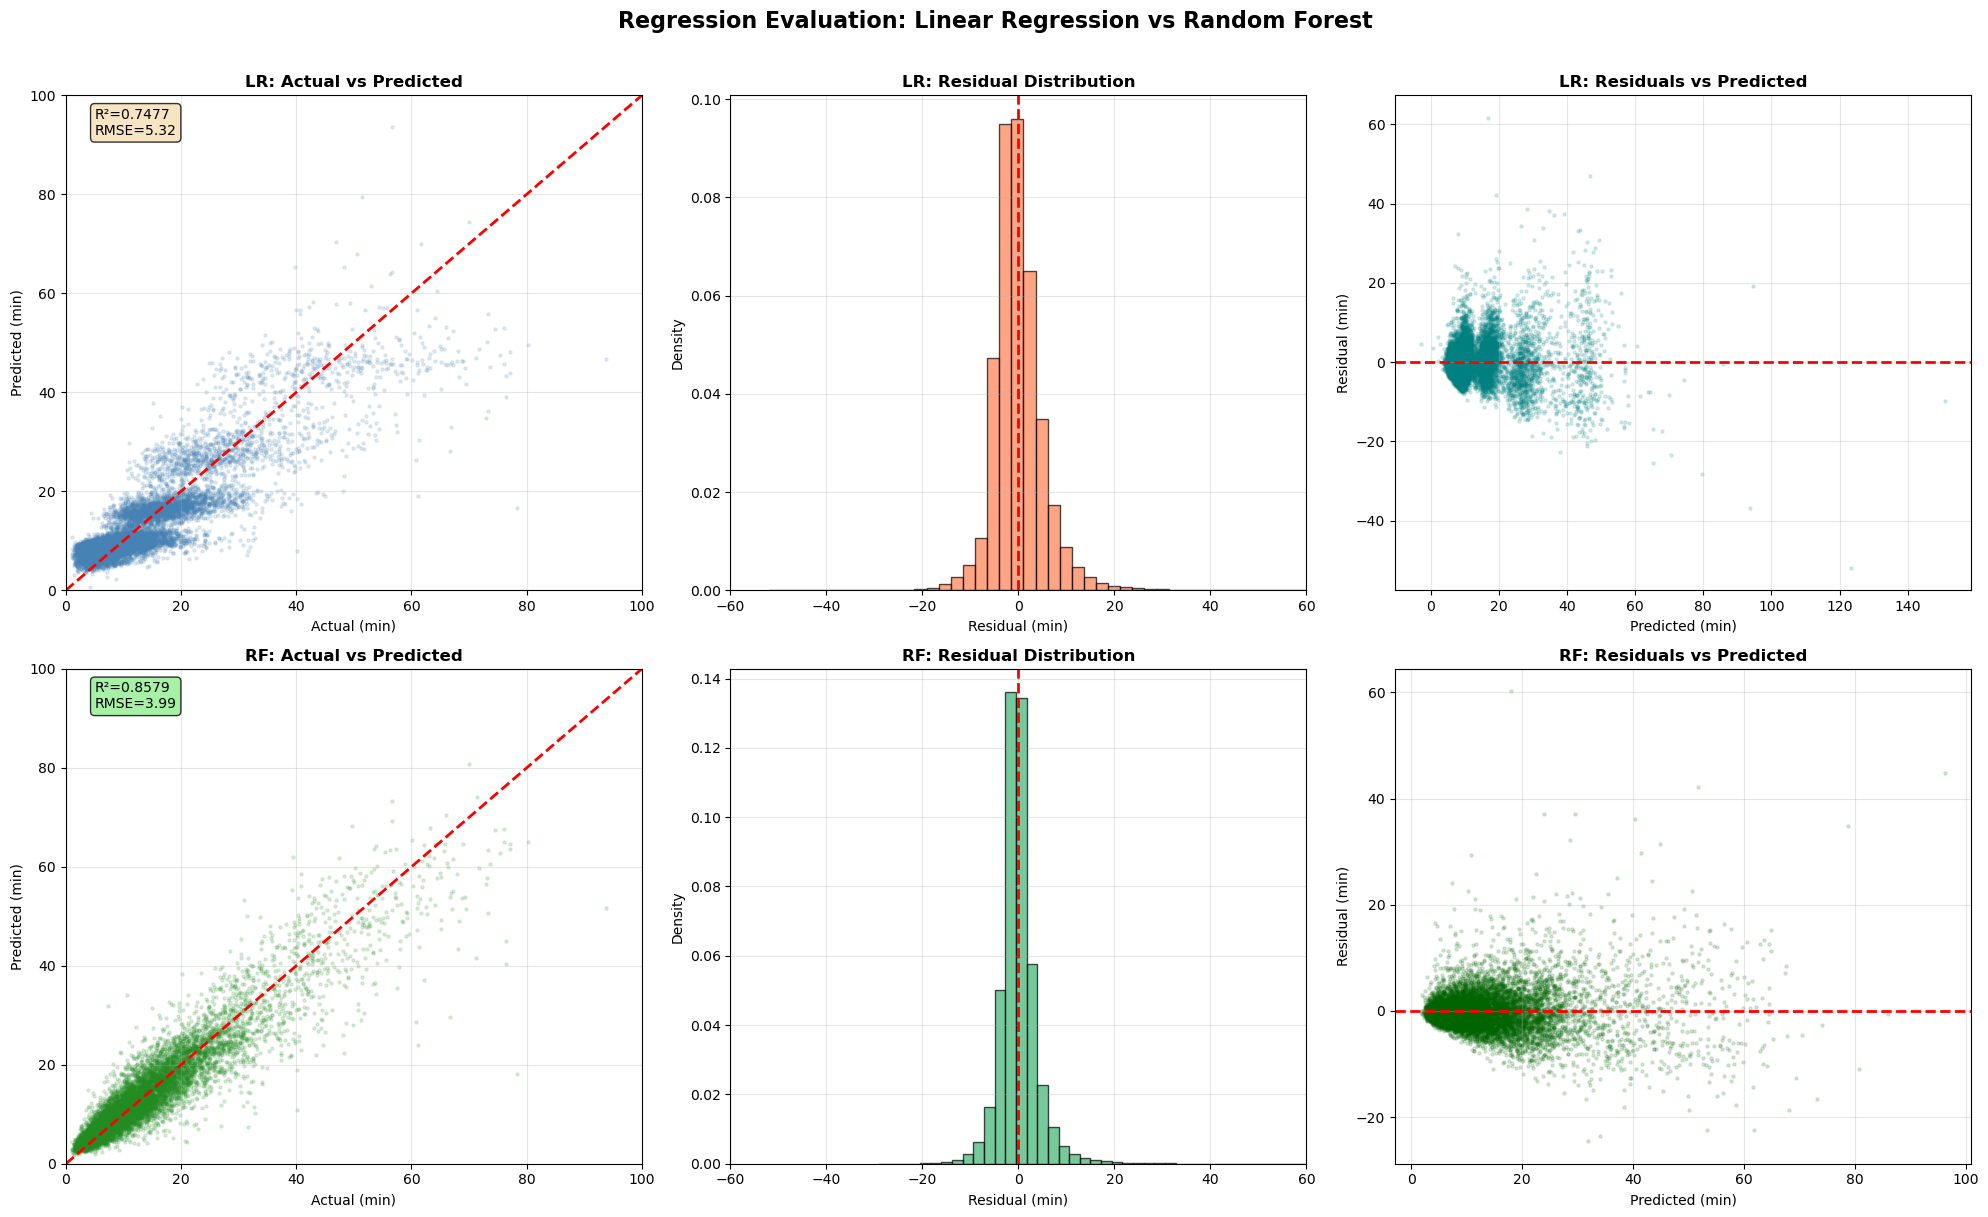

✅ Regression diagnostic plots generated!


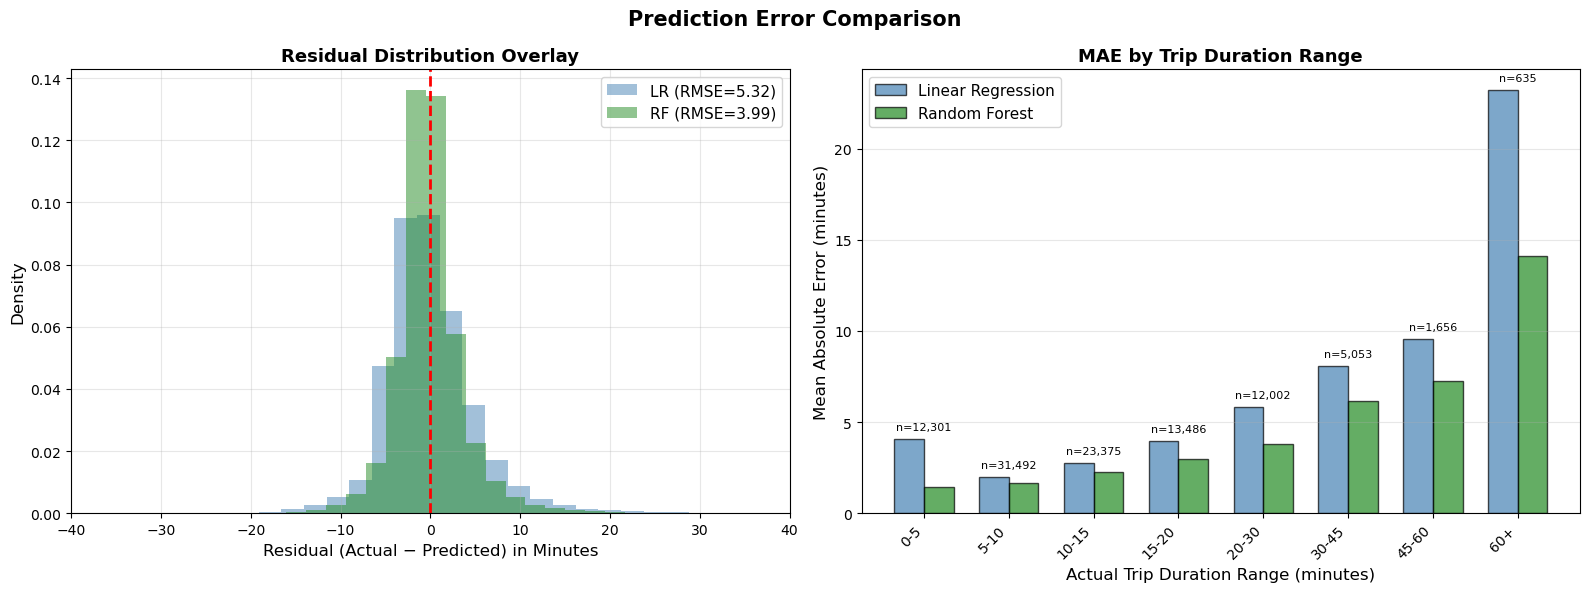

✅ Error comparison plots generated!


In [ ]:
# ## 6. Regression Diagnostic Plots — Side by Side

# %%
n_plot = min(10000, len(y_dur_test))
idx = np.random.RandomState(42).choice(len(y_dur_test), size=n_plot, replace=False)

plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Regression Evaluation: Linear Regression vs Random Forest', 
             fontsize=16, fontweight='bold', y=1.01)


# ── ROW 1: LINEAR REGRESSION ──
lr_residuals = y_dur_test - lr_dur_pred_test

axes[0, 0].scatter(np.array(y_dur_test)[idx], lr_dur_pred_test[idx], alpha=0.15, s=5, color='steelblue')
axes[0, 0].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Actual (min)'); axes[0, 0].set_ylabel('Predicted (min)')
axes[0, 0].set_title('LR: Actual vs Predicted', fontweight='bold')
axes[0, 0].set_xlim(0, 100); axes[0, 0].set_ylim(0, 100); axes[0, 0].grid(alpha=0.3)
axes[0, 0].text(0.05, 0.92, f'R²={lr_test_r2:.4f}\nRMSE={lr_test_rmse:.2f}', 
                transform=axes[0, 0].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

axes[0, 1].hist(lr_residuals, bins=80, color='coral', edgecolor='black', alpha=0.7, density=True)
axes[0, 1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0, 1].set_xlabel('Residual (min)'); axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('LR: Residual Distribution', fontweight='bold')
axes[0, 1].set_xlim(-60, 60); axes[0, 1].grid(alpha=0.3)

axes[0, 2].scatter(lr_dur_pred_test[idx], np.array(lr_residuals)[idx], alpha=0.15, s=5, color='teal')
axes[0, 2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0, 2].set_xlabel('Predicted (min)'); axes[0, 2].set_ylabel('Residual (min)')
axes[0, 2].set_title('LR: Residuals vs Predicted', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# ── ROW 2: RANDOM FOREST ──
rf_residuals = y_dur_test - rf_dur_pred_test

axes[1, 0].scatter(np.array(y_dur_test)[idx], rf_dur_pred_test[idx], alpha=0.15, s=5, color='forestgreen')
axes[1, 0].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[1, 0].set_xlabel('Actual (min)'); axes[1, 0].set_ylabel('Predicted (min)')
axes[1, 0].set_title('RF: Actual vs Predicted', fontweight='bold')
axes[1, 0].set_xlim(0, 100); axes[1, 0].set_ylim(0, 100); axes[1, 0].grid(alpha=0.3)
axes[1, 0].text(0.05, 0.92, f'R²={rf_test_r2:.4f}\nRMSE={rf_test_rmse:.2f}', 
                transform=axes[1, 0].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

axes[1, 1].hist(rf_residuals, bins=80, color='mediumseagreen', edgecolor='black', alpha=0.7, density=True)
axes[1, 1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Residual (min)'); axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('RF: Residual Distribution', fontweight='bold')
axes[1, 1].set_xlim(-60, 60); axes[1, 1].grid(alpha=0.3)

axes[1, 2].scatter(rf_dur_pred_test[idx], np.array(rf_residuals)[idx], alpha=0.15, s=5, color='darkgreen')
axes[1, 2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1, 2].set_xlabel('Predicted (min)'); axes[1, 2].set_ylabel('Residual (min)')
axes[1, 2].set_title('RF: Residuals vs Predicted', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Regression diagnostic plots generated!")

# ## 7. Regression — Error Distribution Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Prediction Error Comparison', fontsize=15, fontweight='bold', y=0.98)

# Plot 1: Overlaid residual distributions
axes[0].hist(lr_residuals, bins=80, alpha=0.5, color='steelblue', label=f'LR (RMSE={lr_test_rmse:.2f})', density=True)
axes[0].hist(rf_residuals, bins=80, alpha=0.5, color='forestgreen', label=f'RF (RMSE={rf_test_rmse:.2f})', density=True)
axes[0].axvline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Residual (Actual − Predicted) in Minutes', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Residual Distribution Overlay', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim(-40, 40)
axes[0].grid(alpha=0.3)

# Plot 2: MAE by duration range
bins = [0, 5, 10, 15, 20, 30, 45, 60, 180]
bin_labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30-45', '45-60', '60+']
y_test_binned = pd.cut(y_dur_test, bins=bins, labels=bin_labels)

error_df = pd.DataFrame({
    'bin': y_test_binned,
    'lr_error': np.abs(np.array(y_dur_test) - lr_dur_pred_test),
    'rf_error': np.abs(np.array(y_dur_test) - rf_dur_pred_test)
})
mae_by_bin = error_df.groupby('bin', observed=True).agg(
    lr_mae=('lr_error', 'mean'),
    rf_mae=('rf_error', 'mean'),
    count=('lr_error', 'count')
).reset_index()

x_pos = np.arange(len(mae_by_bin))
width = 0.35

axes[1].bar(x_pos - width/2, mae_by_bin['lr_mae'], width, color='steelblue', alpha=0.7, label='Linear Regression', edgecolor='black')
axes[1].bar(x_pos + width/2, mae_by_bin['rf_mae'], width, color='forestgreen', alpha=0.7, label='Random Forest', edgecolor='black')
axes[1].set_xlabel('Actual Trip Duration Range (minutes)', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error (minutes)', fontsize=12)
axes[1].set_title('MAE by Trip Duration Range', fontweight='bold', fontsize=13)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(mae_by_bin['bin'], rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Add count labels
for i, count in enumerate(mae_by_bin['count']):
    axes[1].text(i, max(mae_by_bin['lr_mae'].iloc[i], mae_by_bin['rf_mae'].iloc[i]) + 0.5,
                 f'n={count:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print("✅ Error comparison plots generated!")

### 2.5 Regression Feature Importance

This keeps the coefficient-based Linear Regression view next to Random Forest feature importances.


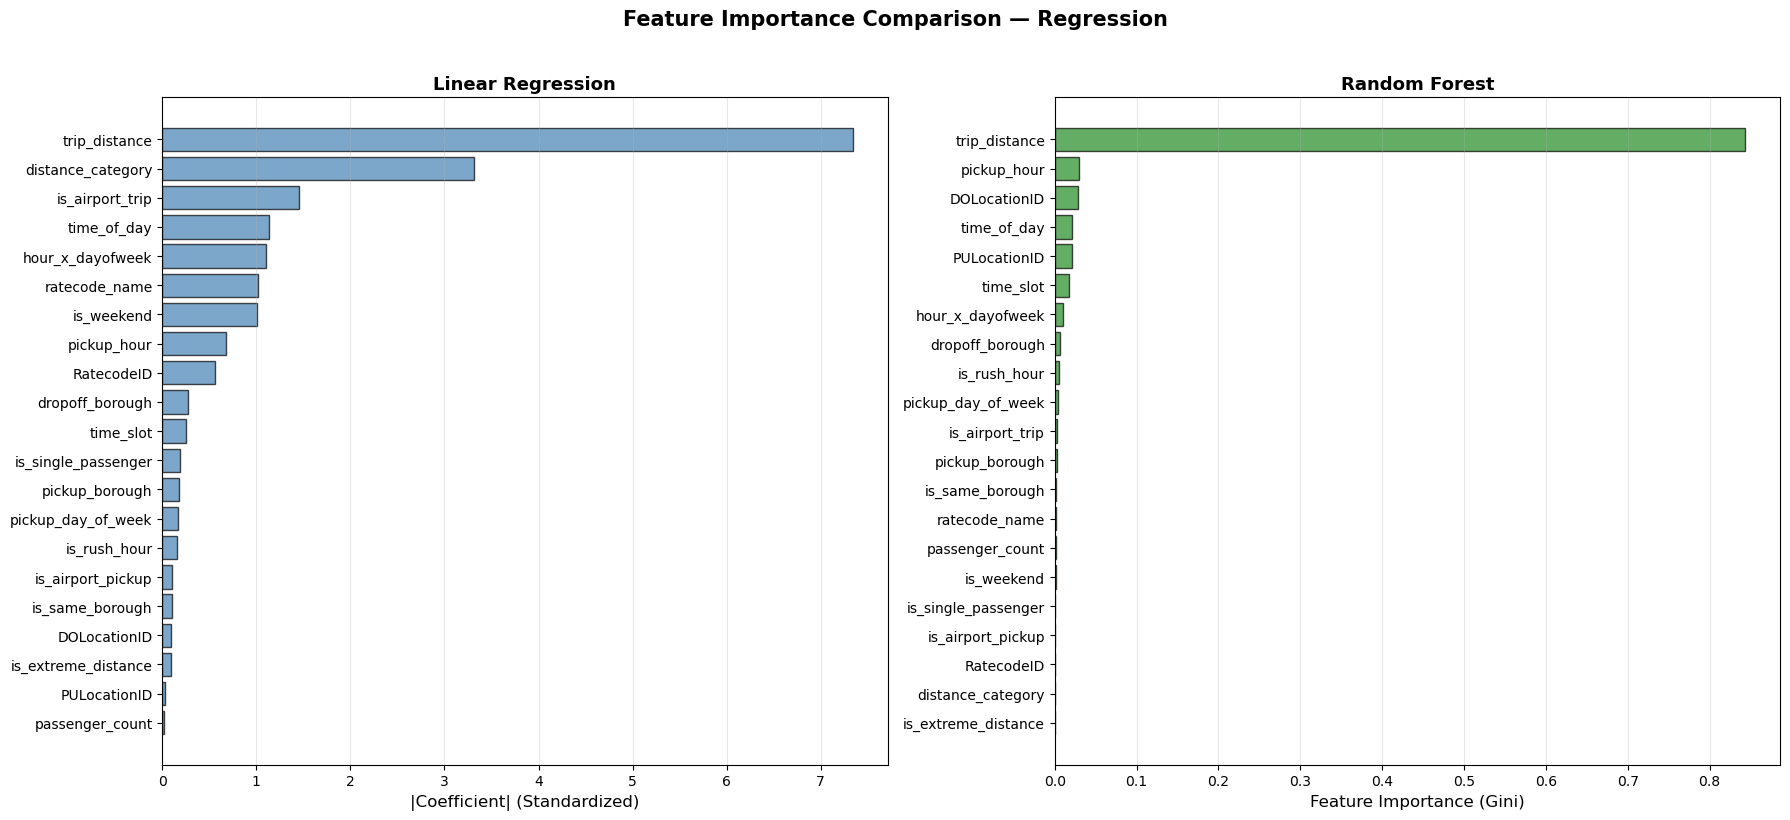

✅ Feature importance comparison generated!


In [ ]:
# ## 8. Regression — Feature Importance Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Comparison — Regression', fontsize=15, fontweight='bold', y=1.02)

# LR coefficients (absolute)
lr_coef = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(lr_reg.coef_)
}).sort_values('Importance', ascending=True)

axes[0].barh(lr_coef['Feature'], lr_coef['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('|Coefficient| (Standardized)', fontsize=12)
axes[0].set_title('Linear Regression', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

# RF feature importance
rf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_imp['Feature'], rf_imp['Importance'], color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Feature Importance (Gini)', fontsize=12)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Feature importance comparison generated!")

### 2.6 Classification Metrics

This keeps Abhishek's congestion-fee metrics and classification reports for Logistic Regression and Random Forest.


In [ ]:
# # PART B: Classification Evaluation — Congestion Fee
# 
# Comparing Logistic Regression vs Random Forest on Accuracy, AUC, F1, 
# Precision, and Recall.

# %% [markdown]
# ---
# ## 9. Classification Metrics Comparison

# %%
print("="*70)
print("CLASSIFICATION EVALUATION: Logistic Regression vs Random Forest")
print("="*70)

# Logistic Regression metrics
lr_clf_accuracy = accuracy_score(y_cong_test, lr_cong_pred)
lr_clf_auc = roc_auc_score(y_cong_test, lr_cong_proba)
lr_clf_f1 = f1_score(y_cong_test, lr_cong_pred)
lr_clf_precision = precision_score(y_cong_test, lr_cong_pred)
lr_clf_recall = recall_score(y_cong_test, lr_cong_pred)
lr_train_acc = accuracy_score(y_cong_train, lr_cong_pred_train)

# Random Forest metrics
rf_clf_accuracy = accuracy_score(y_cong_test, rf_cong_pred)
rf_clf_auc = roc_auc_score(y_cong_test, rf_cong_proba)
rf_clf_f1 = f1_score(y_cong_test, rf_cong_pred)
rf_clf_precision = precision_score(y_cong_test, rf_cong_pred)
rf_clf_recall = recall_score(y_cong_test, rf_cong_pred)
rf_train_acc = accuracy_score(y_cong_train, rf_cong_pred_train)

print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("─" * 77)
print(f"{'Naive (predict YES)':<25} {naive_cong_accuracy:>10.4f} {'—':>10} {'—':>10} {'—':>10} {'—':>10}")
print(f"{'Logistic Regression':<25} {lr_clf_accuracy:>10.4f} {lr_clf_auc:>10.4f} {lr_clf_f1:>10.4f} {lr_clf_precision:>10.4f} {lr_clf_recall:>10.4f}")
print(f"{'Random Forest':<25} {rf_clf_accuracy:>10.4f} {rf_clf_auc:>10.4f} {rf_clf_f1:>10.4f} {rf_clf_precision:>10.4f} {rf_clf_recall:>10.4f}")

print(f"\n📊 RF IMPROVEMENT OVER LOGISTIC REGRESSION:")
auc_imp = ((rf_clf_auc - lr_clf_auc) / lr_clf_auc) * 100
f1_imp = ((rf_clf_f1 - lr_clf_f1) / lr_clf_f1) * 100
print(f"   AUC: {auc_imp:+.1f}%")
print(f"   F1:  {f1_imp:+.1f}%")

print(f"\n📊 OVERFITTING COMPARISON:")
print(f"   Logistic Regression: Train Acc = {lr_train_acc:.4f}, Test Acc = {lr_clf_accuracy:.4f}, Gap = {abs(lr_train_acc - lr_clf_accuracy):.4f}")
print(f"   Random Forest:       Train Acc = {rf_train_acc:.4f}, Test Acc = {rf_clf_accuracy:.4f}, Gap = {abs(rf_train_acc - rf_clf_accuracy):.4f}")

# Classification Reports
print("\n" + "="*70)
print("LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_cong_test, lr_cong_pred, target_names=["No Fee (0)", "Has Fee (1)"]))

print("="*70)
print("RANDOM FOREST — CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_cong_test, rf_cong_pred, target_names=["No Fee (0)", "Has Fee (1)"]))

CLASSIFICATION EVALUATION: Logistic Regression vs Random Forest

Model                       Accuracy        AUC         F1  Precision     Recall
─────────────────────────────────────────────────────────────────────────────
Naive (predict YES)           0.7438          —          —          —          —
Logistic Regression           0.7750     0.7336     0.8661     0.7770     0.9783
Random Forest                 0.9533     0.9794     0.9684     0.9759     0.9609

📊 RF IMPROVEMENT OVER LOGISTIC REGRESSION:
   AUC: +33.5%
   F1:  +11.8%

📊 OVERFITTING COMPARISON:
   Logistic Regression: Train Acc = 0.7742, Test Acc = 0.7750, Gap = 0.0008
   Random Forest:       Train Acc = 0.9637, Test Acc = 0.9533, Gap = 0.0104



LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Fee (0)       0.75      0.18      0.30     25625
 Has Fee (1)       0.78      0.98      0.87     74375

    accuracy                           0.77    100000
   macro avg       0.76      0.58      0.58    100000
weighted avg       0.77      0.77      0.72    100000

RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Fee (0)       0.89      0.93      0.91     25625
 Has Fee (1)       0.98      0.96      0.97     74375

    accuracy                           0.95    100000
   macro avg       0.93      0.95      0.94    100000
weighted avg       0.95      0.95      0.95    100000



### 2.7 Classification Diagnostics and Probability Checks

These plots preserve Abhishek's confusion matrices, ROC curves, predicted-probability distributions, and classifier feature importance comparison.


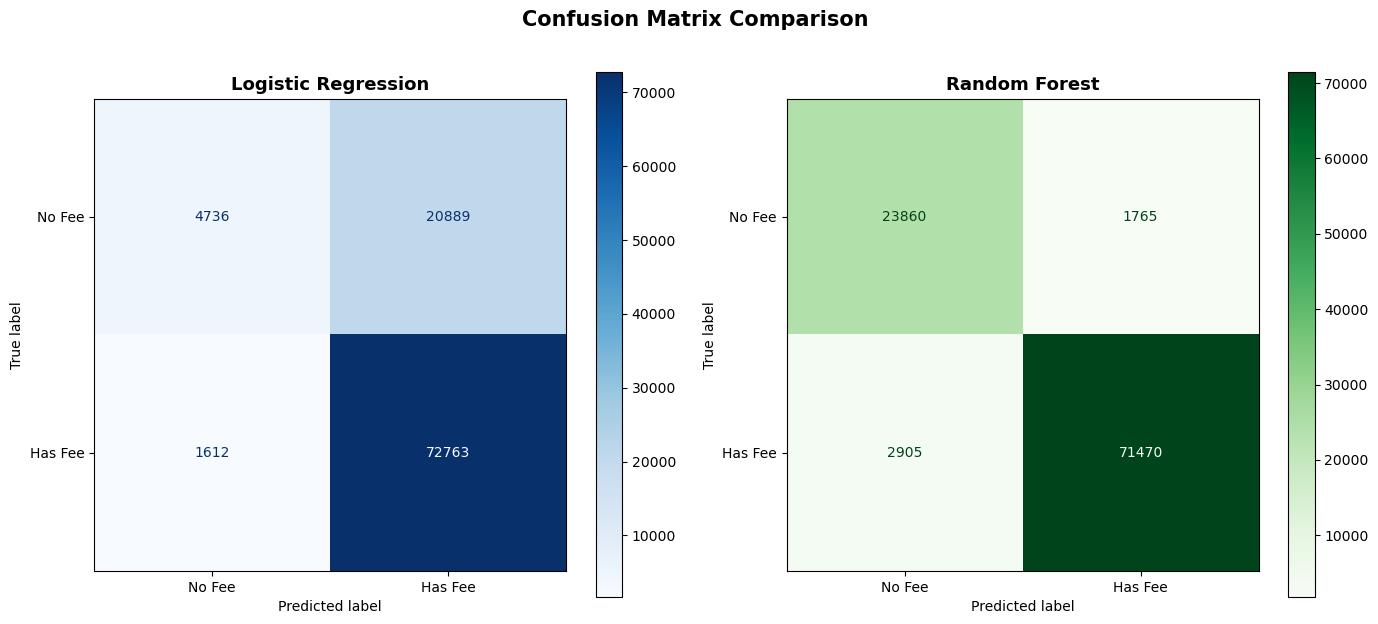

✅ Confusion matrices generated!


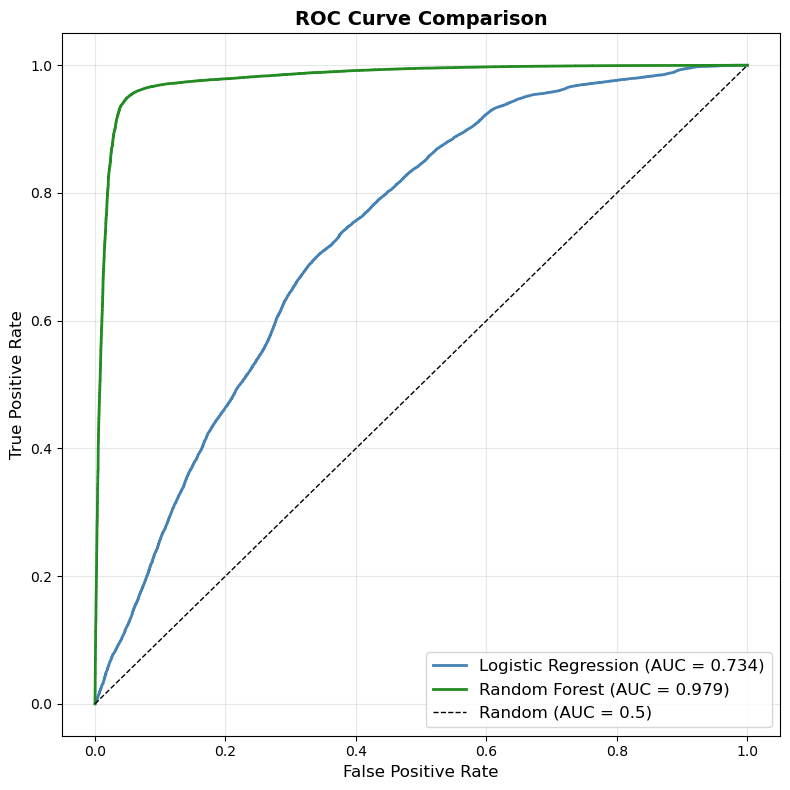

✅ ROC curve comparison generated!


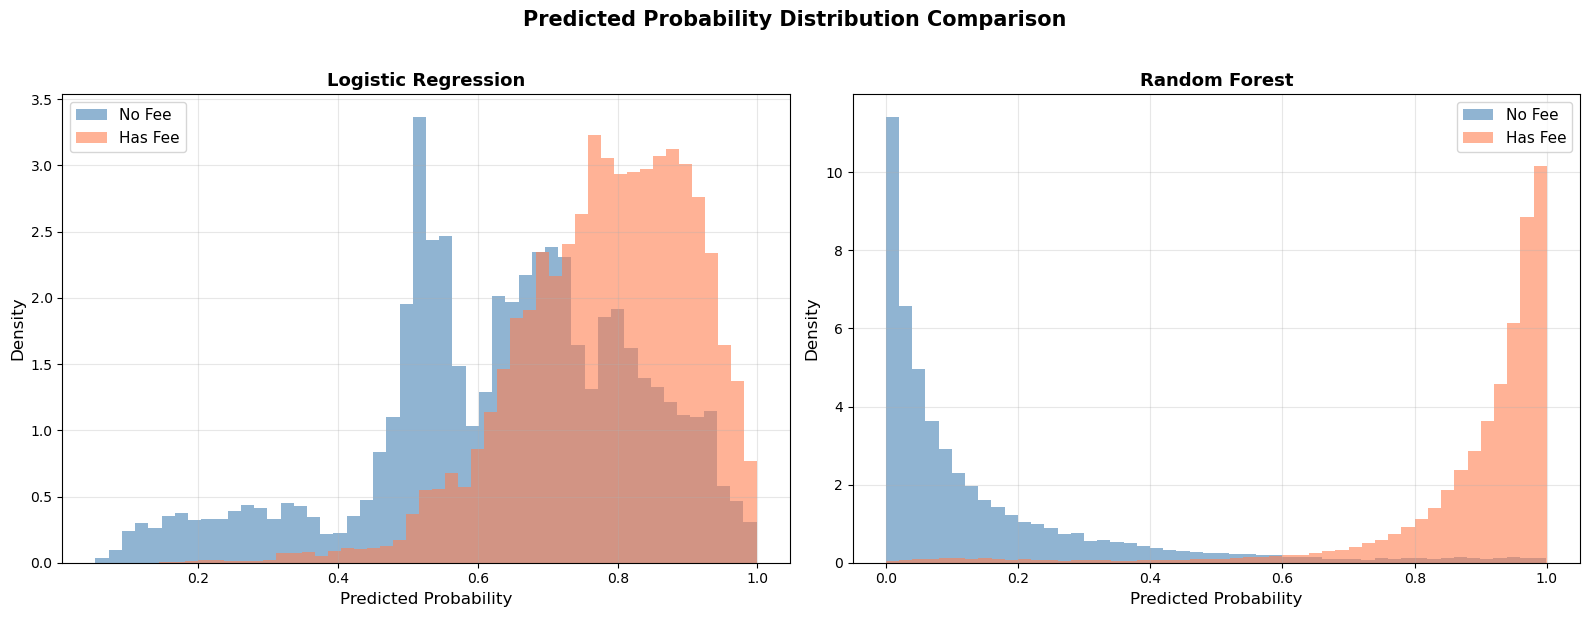

✅ Probability distribution comparison generated!


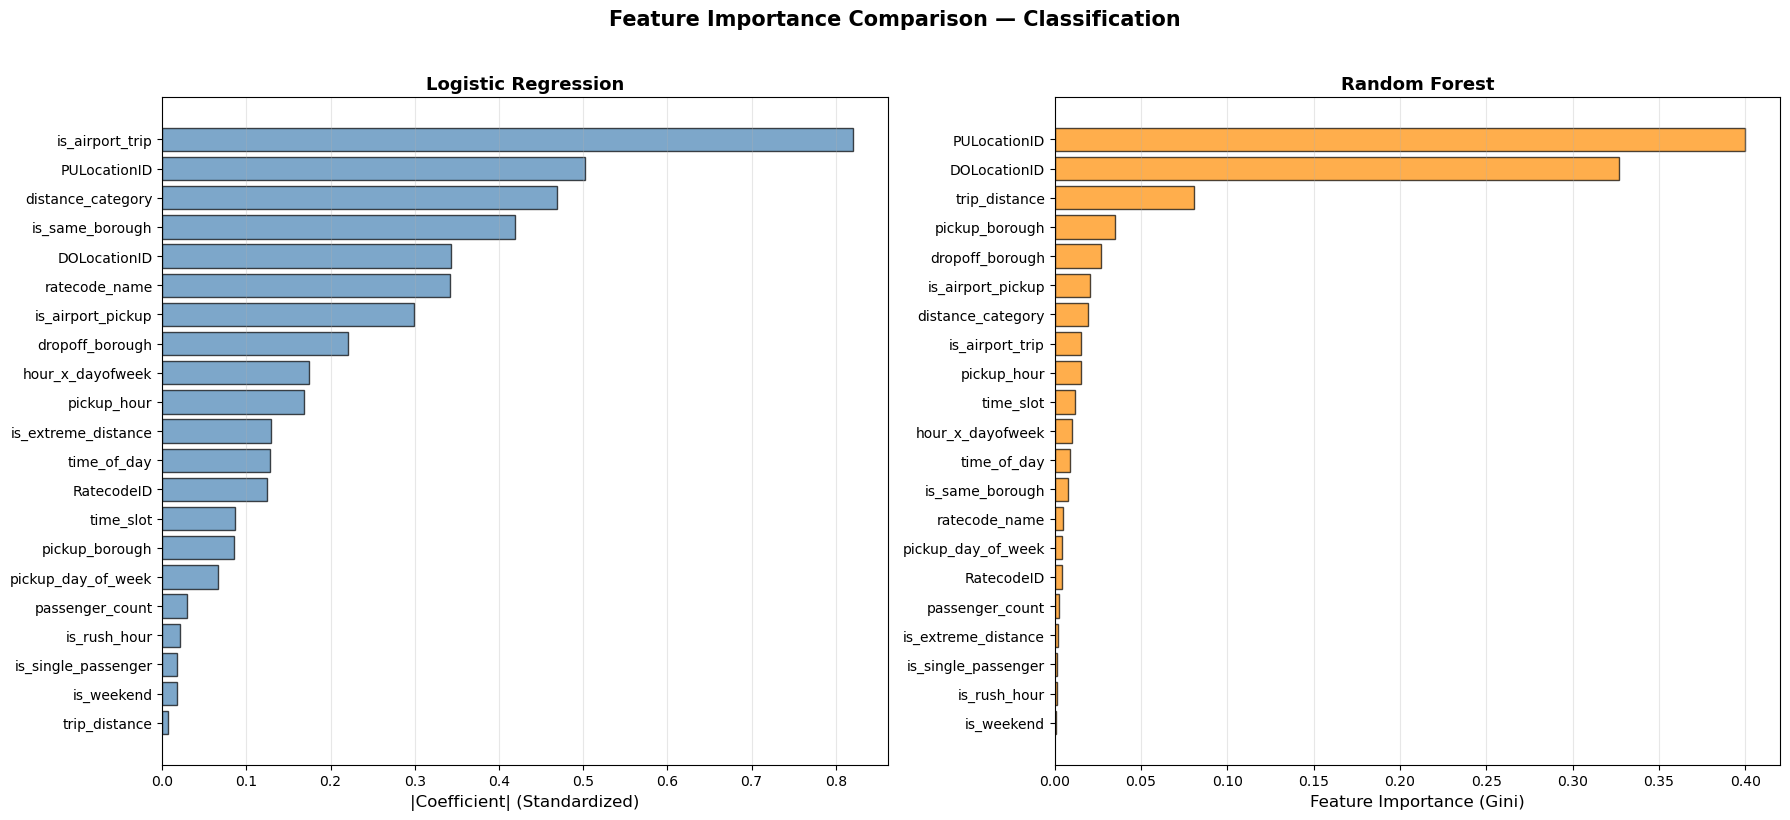

✅ Classification feature importance comparison generated!


In [ ]:
# ## 10. Classification — Confusion Matrices Side by Side

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)

ConfusionMatrixDisplay.from_predictions(
    y_cong_test, lr_cong_pred,
    display_labels=["No Fee", "Has Fee"],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)

ConfusionMatrixDisplay.from_predictions(
    y_cong_test, rf_cong_pred,
    display_labels=["No Fee", "Has Fee"],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()
print("✅ Confusion matrices generated!")

# ## 11. Classification — ROC Curves Comparison

# %%
fig, ax = plt.subplots(figsize=(8, 8))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_cong_test, lr_cong_proba)
ax.plot(lr_fpr, lr_tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {lr_clf_auc:.3f})')

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_cong_test, rf_cong_proba)
ax.plot(rf_fpr, rf_tpr, color='forestgreen', linewidth=2, label=f'Random Forest (AUC = {rf_clf_auc:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ ROC curve comparison generated!")

# ## 12. Classification — Predicted Probability Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Predicted Probability Distribution Comparison', fontsize=15, fontweight='bold', y=1.02)

# Logistic Regression
axes[0].hist(lr_cong_proba[y_cong_test == 0], bins=50, alpha=0.6, color='steelblue', label='No Fee', density=True)
axes[0].hist(lr_cong_proba[y_cong_test == 1], bins=50, alpha=0.6, color='coral', label='Has Fee', density=True)
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].hist(rf_cong_proba[y_cong_test == 0], bins=50, alpha=0.6, color='steelblue', label='No Fee', density=True)
axes[1].hist(rf_cong_proba[y_cong_test == 1], bins=50, alpha=0.6, color='coral', label='Has Fee', density=True)
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Probability distribution comparison generated!")

# ## 13. Classification — Feature Importance Comparison

# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Comparison — Classification', fontsize=15, fontweight='bold', y=1.02)

# Logistic Regression coefficients (absolute)
lr_clf_coef = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(lr_clf.coef_[0])
}).sort_values('Importance', ascending=True)

axes[0].barh(lr_clf_coef['Feature'], lr_clf_coef['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('|Coefficient| (Standardized)', fontsize=12)
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)

# RF feature importance
rf_clf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_clf_imp['Feature'], rf_clf_imp['Importance'], color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Feature Importance (Gini)', fontsize=12)
axes[1].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Classification feature importance comparison generated!")

### 2.8 Abhishek Summary

The source notebook closes with a combined summary of trip-duration and congestion-fee model performance.


In [ ]:
# ## 14. Final Combined Summary

# %%
print("="*70)
print("FINAL EVALUATION SUMMARY — Abhishek's Models")
print("="*70)

print(f"""
{'─'*70}
  REGRESSION: Trip Duration Prediction
{'─'*70}

  {'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Overfit Gap':>12}
  {'─'*61}
  {'Naive (predict mean)':<25} {naive_dur_rmse:>8.2f} {'—':>8} {'—':>8} {'—':>12}
  {'Linear Regression':<25} {lr_test_rmse:>8.2f} {lr_test_mae:>8.2f} {lr_test_r2:>8.4f} {abs(lr_train_rmse - lr_test_rmse):>11.2f}m
  {'Random Forest':<25} {rf_test_rmse:>8.2f} {rf_test_mae:>8.2f} {rf_test_r2:>8.4f} {abs(rf_train_rmse - rf_test_rmse):>11.2f}m

  RF improvement over LR: RMSE {rmse_improvement:+.1f}% | MAE {mae_improvement:+.1f}% | R² {r2_improvement:+.1f}%
  Stakeholder Goal (RMSE < 10): Both models ✅

{'─'*70}
  CLASSIFICATION: Congestion Fee Prediction
{'─'*70}

  {'Model':<25} {'Accuracy':>10} {'AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}
  {'─'*70}
  {'Naive (predict YES)':<25} {naive_cong_accuracy:>10.4f} {'—':>8} {'—':>8} {'—':>10} {'—':>8}
  {'Logistic Regression':<25} {lr_clf_accuracy:>10.4f} {lr_clf_auc:>8.4f} {lr_clf_f1:>8.4f} {lr_clf_precision:>10.4f} {lr_clf_recall:>8.4f}
  {'Random Forest':<25} {rf_clf_accuracy:>10.4f} {rf_clf_auc:>8.4f} {rf_clf_f1:>8.4f} {rf_clf_precision:>10.4f} {rf_clf_recall:>8.4f}

  RF improvement over LR: AUC {auc_imp:+.1f}% | F1 {f1_imp:+.1f}%

{'─'*70}
  KEY TAKEAWAYS
{'─'*70}
  1. Random Forest significantly outperforms Linear/Logistic baselines on both tasks
  2. RF captures non-linear patterns (location × time interactions) that linear models miss
  3. Overfitting is controlled with max_depth=30 and min_samples_leaf=5
  4. For regression, trip_distance is the dominant predictor in both models
  5. For classification, location features (PULocationID, DOLocationID) drive predictions
     — confirming the stakeholder insight that congestion fee is fundamentally spatial
""")

print("="*70)
print("✅ Abhishek's model evaluation complete!")
print("="*70)

FINAL EVALUATION SUMMARY — Abhishek's Models

──────────────────────────────────────────────────────────────────────
  REGRESSION: Trip Duration Prediction
──────────────────────────────────────────────────────────────────────

  Model                         RMSE      MAE       R²  Overfit Gap
  ─────────────────────────────────────────────────────────────
  Naive (predict mean)         10.59        —        —            —
  Linear Regression             5.32     3.72   0.7477        0.08m
  Random Forest                 3.99     2.61   0.8579        0.89m

  RF improvement over LR: RMSE +25.0% | MAE +29.9% | R² +14.7%
  Stakeholder Goal (RMSE < 10): Both models ✅

──────────────────────────────────────────────────────────────────────
  CLASSIFICATION: Congestion Fee Prediction
──────────────────────────────────────────────────────────────────────

  Model                       Accuracy      AUC       F1  Precision   Recall
  ───────────────────────────────────────────────────────────

## 3. Advanced Congestion-Fee Classification

From **Morgan_mod_eval.ipynb**. Morgan compares Logistic Regression, Random Forest, and XGBoost for `has_congestion_fee` using confusion matrices, accuracy, F1 score, and hourly performance checks.


### 3.1 Data Preparation and Model Training

This section uses Morgan's 500,000-row sample, the same dropped columns used by the baseline evaluations, scaled inputs for Logistic Regression, and encoded feature inputs for Random Forest and XGBoost.


In [ ]:
# load data and sample
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
data = data.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

# drop unnecessary columns and encode categoricals
y_congestion = data["has_congestion_fee"]
y_duration = data["trip_duration_min"]

drop_cols = [
    "trip_duration_min",
    "has_congestion_fee",
    "tpep_pickup_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]
existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    if X[col].dtype.name == "category":
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])

X_train, X_test, _, _, y_train, y_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_congestion,
)

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

print(f"Train {X_train.shape[0]:,} | Test {X_test.shape[0]:,} | Features {X_train.shape[1]}")

Train 400,000 | Test 100,000 | Features 21


In [ ]:
# train models and fit

# Logistic Regression
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=2500, class_weight="balanced")
lr_model.fit(X_train_lr, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

### 3.2 Accuracy and F1 Comparison

From **Morgan_mod_eval.ipynb**. The metrics table shows that XGBoost has the strongest F1 score, with Random Forest close behind.


In [ ]:
# compare metrics (accuracy, F1-score)
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}   

results = []
for name, model in models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_lr)
    else:
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})

print("\nModel Performance:")
for result in results:
    print(f"    {result['Model']}: Accuracy = {result['Accuracy']:.4f}, F1 Score = {result['F1 Score']:.4f}")


Model Performance:
    Logistic Regression: Accuracy = 0.6673, F1 Score = 0.7469
    Random Forest: Accuracy = 0.9535, F1 Score = 0.9685
    XGBoost: Accuracy = 0.9639, F1 Score = 0.9755


### 3.3 Confusion Matrices

From **Morgan_mod_eval.ipynb**. The confusion matrices show where the classifiers make false-positive and false-negative congestion-fee mistakes.


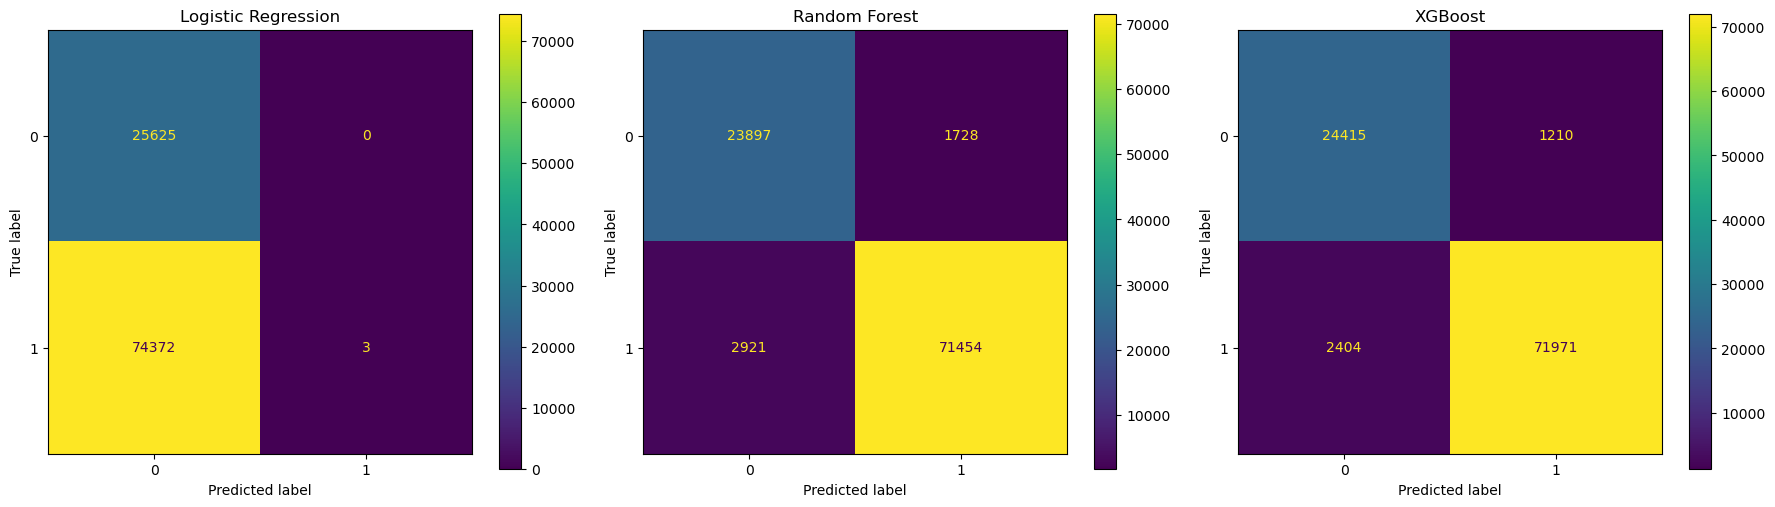

In [ ]:
# plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 3.4 Hourly Group Checks

From **Morgan_mod_eval.ipynb**. The best model is evaluated by pickup hour to check whether performance changes across the day.


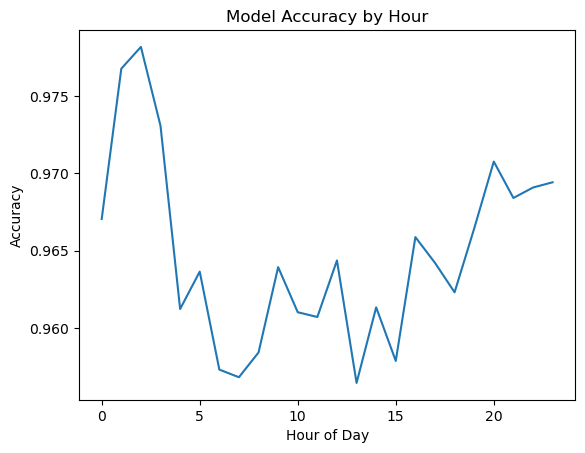

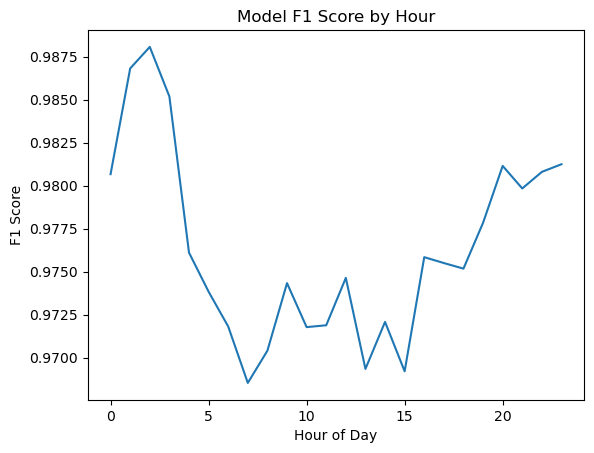

In [ ]:
# get predictions from your best model
y_pred = xgb_model.predict(X_test)

# make sure X_test is a DataFrame and has pickup_hour
results = X_test.copy()
results["actual"] = y_test
results["pred"] = y_pred

# accuracy by hour
hourly_acc = results.groupby("pickup_hour").apply(
    lambda x: (x["actual"] == x["pred"]).mean()
)

# F1 by hour
hourly_f1 = results.groupby("pickup_hour").apply(
    lambda x: f1_score(x["actual"], x["pred"])
)

# plot
plt.figure()
hourly_acc.plot()
plt.title("Model Accuracy by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
hourly_f1.plot()
plt.title("Model F1 Score by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("F1 Score")
plt.show()

Morgan's source notebook notes that model performance varies slightly by hour, with lower accuracy during late afternoon and evening peak periods. This suggests congestion-fee patterns during rush hours are more complex and harder for the model to predict.


## 4. ROC-AUC and Ranking Quality

From **Moses_mod_eval.ipynb**. Moses evaluates the same congestion-fee model family with ROC curves and ROC-AUC, using the same test data for a fair ranking comparison.


### 4.1 Data Preparation and Model Training

This repeats the classification preparation from Moses's notebook so the ROC-AUC comparison can be reproduced independently.


In [ ]:
# Load + sample + features (same rules as Abhishek_RF / Moses_RF)
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
data = data.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

y_congestion = data["has_congestion_fee"]
y_duration = data["trip_duration_min"]

drop_cols = [
    "trip_duration_min",
    "has_congestion_fee",
    "tpep_pickup_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]
existing_drops = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing_drops)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    if X[col].dtype.name == "category":
        X[col] = X[col].astype(str)
    X[col] = X[col].fillna("Unknown")
    X[col] = le.fit_transform(X[col])

X_train, X_test, _, _, y_train, y_test = train_test_split(
    X, y_duration, y_congestion,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_congestion,
)

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

print(f"Train {X_train.shape[0]:,} | Test {X_test.shape[0]:,} | Features {X_train.shape[1]}")
print(f"Test positive rate (fee): {y_test.mean():.3f}")

# Fit models (same train; probabilities on same test)
models = {}

lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")
lr.fit(X_train_lr, y_train)
models["Logistic regression"] = (lr, X_test_lr)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
models["Random Forest"] = (rf, X_test)

if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss",
    )
    xgb.fit(X_train, y_train)
    models["XGBoost"] = (xgb, X_test)

print("Fitted:", ", ".join(models.keys()))

Train 400,000 | Test 100,000 | Features 21
Test positive rate (fee): 0.744


Fitted: Logistic regression, Random Forest, XGBoost


### 4.2 ROC Curves and AUC Table

The ROC plot and AUC table compare how well each classifier ranks trips by congestion-fee likelihood.


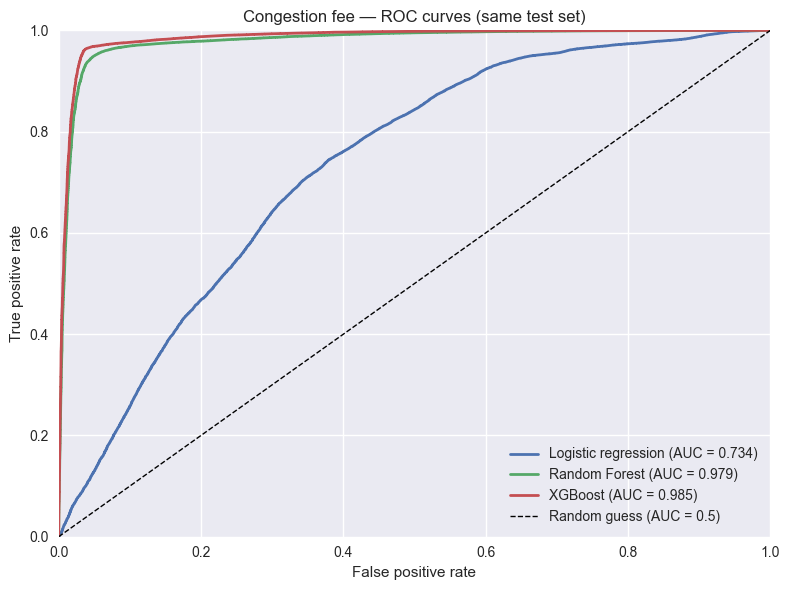

              Model  Test ROC-AUC
            XGBoost        0.9850
      Random Forest        0.9794
Logistic regression        0.7336


In [ ]:
# ROC curves + AUC table
fig, ax = plt.subplots(figsize=(8, 6))

rows = []
for name, (clf, X_te) in models.items():
    proba = clf.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")
    rows.append({"Model": name, "Test ROC-AUC": round(float(auc), 4)})

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess (AUC = 0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Congestion fee — ROC curves (same test set)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

auc_table = pd.DataFrame(rows).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
print(auc_table.to_string(index=False))

### 4.3 Moses Takeaways

From **Moses_mod_eval.ipynb**.

- XGBoost has the highest test ROC-AUC, slightly ahead of Random Forest.
- Both tree-based models are far above random guessing and clearly outperform Logistic Regression.
- The result supports using nonlinear ensemble methods because location, time, and interaction effects are not captured well by one linear score.


## 5. Advanced Trip-Duration Evaluation

From **Tarun_mod_eval.ipynb**. This section rebuilds the XGBoost trip-duration workflow from `Tarun_XGB.ipynb` so residuals, group summaries, and worst prediction cases can be evaluated.


In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")

SEED = 42
SAMPLE_SIZE = 150_000

COMMON_DROP_COLUMNS = [
    "tpep_pickup_datetime",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "Airport_fee",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]

KNOWN_CATEGORICAL_COLUMNS = [
    "PULocationID",
    "DOLocationID",
    "RatecodeID",
    "pickup_hour",
    "pickup_day_of_week",
    "time_slot",
    "time_of_day",
    "pickup_borough",
    "dropoff_borough",
    "distance_category",
    "ratecode_name",
]


def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "processed" / "taxi_engineered.parquet").exists():
            return candidate
    raise FileNotFoundError("Could not find project root from the current working directory.")


def make_stratified_sample(frame, sample_size, stratify_col, random_state=SEED):
    if sample_size >= len(frame):
        return frame.copy()

    sampled_index, _ = train_test_split(
        frame.index,
        train_size=sample_size,
        stratify=frame[stratify_col],
        random_state=random_state,
    )
    return frame.loc[sampled_index].copy().sort_index()


def prepare_features(frame, target_name, extra_drop_columns):
    drop_columns = [target_name, *extra_drop_columns, *COMMON_DROP_COLUMNS]
    existing_drop_columns = [column for column in drop_columns if column in frame.columns]

    X = frame.drop(columns=existing_drop_columns).copy()
    y = frame[target_name].copy()

    detected_categorical = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    categorical_columns = sorted(
        set(detected_categorical).union(column for column in KNOWN_CATEGORICAL_COLUMNS if column in X.columns)
    )

    for column in categorical_columns:
        X[column] = X[column].astype("string").fillna("__MISSING__").astype("category")

    return X, y, categorical_columns


def group_error_summary(frame, group_col, order=None):
    summary = (
        frame.groupby(group_col)
        .agg(
            trips=("residual", "size"),
            mean_actual=("actual_duration_min", "mean"),
            mean_predicted=("predicted_duration_min", "mean"),
            mae=("abs_error", "mean"),
            rmse=("residual", lambda values: float(np.sqrt(np.mean(np.square(values))))),
            mean_residual=("residual", "mean"),
            median_abs_error=("abs_error", "median"),
        )
        .reset_index()
    )

    if order is not None:
        summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
        summary = summary.sort_values(group_col).reset_index(drop=True)
        summary[group_col] = summary[group_col].astype(str)

    return summary

### 5.1 Rebuild XGBoost Duration Predictions

Tarun's evaluation uses a stratified 150,000-row sample, native categorical handling in XGBoost, and a train/validation/test split with early stopping.


In [ ]:
PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "taxi_engineered.parquet"

data = pd.read_parquet(DATA_PATH)
model_data = make_stratified_sample(
    frame=data,
    sample_size=SAMPLE_SIZE,
    stratify_col="has_congestion_fee",
    random_state=SEED,
)

X_duration, y_duration, duration_categorical_columns = prepare_features(
    frame=model_data,
    target_name="trip_duration_min",
    extra_drop_columns=["has_congestion_fee"],
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_duration,
    y_duration,
    test_size=0.20,
    random_state=SEED,
)
X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_train_d,
    y_train_d,
    test_size=0.20,
    random_state=SEED,
)

duration_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

duration_xgb.fit(
    X_train_d,
    y_train_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=False,
)

duration_pred = duration_xgb.predict(X_test_d)

context_columns = [
    "trip_distance",
    "pickup_hour",
    "pickup_day_of_week",
    "time_of_day",
    "is_rush_hour",
    "distance_category",
    "pickup_borough",
    "dropoff_borough",
    "is_airport_trip",
    "is_same_borough",
    "PULocationID",
    "DOLocationID",
    "RatecodeID",
]
available_context_columns = [column for column in context_columns if column in model_data.columns]

eval_results = model_data.loc[X_test_d.index, available_context_columns].copy()
eval_results["actual_duration_min"] = y_test_d
eval_results["predicted_duration_min"] = duration_pred
eval_results["residual"] = eval_results["actual_duration_min"] - eval_results["predicted_duration_min"]
eval_results["abs_error"] = eval_results["residual"].abs()

if "is_rush_hour" in eval_results.columns:
    eval_results["rush_hour_group"] = np.where(
        eval_results["is_rush_hour"] == 1,
        "Rush hour",
        "Non-rush hour",
    )
else:
    eval_results["rush_hour_group"] = np.where(
        eval_results["pickup_hour"].between(7, 9) | eval_results["pickup_hour"].between(17, 19),
        "Rush hour",
        "Non-rush hour",
    )

if "distance_category" in eval_results.columns:
    eval_results["trip_length_group"] = (
        eval_results["distance_category"].astype("string").fillna("unknown").astype(str)
    )
else:
    eval_results["trip_length_group"] = pd.cut(
        eval_results["trip_distance"],
        bins=[0, 2, 5, np.inf],
        labels=["short", "medium", "long"],
        include_lowest=True,
    ).astype(str)

if {"pickup_borough", "dropoff_borough"}.issubset(eval_results.columns):
    eval_results["borough_route"] = (
        eval_results["pickup_borough"].astype(str) + " -> " + eval_results["dropoff_borough"].astype(str)
    )

regression_metrics = {
    "MAE (minutes)": float(mean_absolute_error(y_test_d, duration_pred)),
    "RMSE (minutes)": float(np.sqrt(mean_squared_error(y_test_d, duration_pred))),
    "R^2": float(r2_score(y_test_d, duration_pred)),
    "Best validation RMSE": float(duration_xgb.best_score),
    "Best boosting round": int(duration_xgb.best_iteration),
}

rush_summary = group_error_summary(
    eval_results,
    "rush_hour_group",
    order=["Non-rush hour", "Rush hour"],
)
distance_summary = group_error_summary(
    eval_results,
    "trip_length_group",
    order=["short", "medium", "long", "unknown"],
)

worst_cases = (
    eval_results.sort_values("abs_error", ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"index": "row_id"})
)
worst20 = eval_results.sort_values("abs_error", ascending=False).head(20).copy()

print(f"Data path: {DATA_PATH}")
print(f"Sample size used for modeling: {len(model_data):,}")
print(f"Train / validation / test rows: {len(X_train_d):,} / {len(X_val_d):,} / {len(X_test_d):,}")
print(f"Features used by the regressor: {X_duration.shape[1]}")
print(f"Categorical columns handled by XGBoost: {len(duration_categorical_columns)}")

Data path: C:\Users\Tarun\OneDrive\Syracuse University\IST 707 - Applied Machine Learning\Group Project\group-project-avengers\group-project-avengers\data\processed\taxi_engineered.parquet
Sample size used for modeling: 150,000
Train / validation / test rows: 96,000 / 24,000 / 30,000
Features used by the regressor: 21
Categorical columns handled by XGBoost: 11


### 5.2 Overall Model Fit

The XGBoost duration model is evaluated with MAE, RMSE, R^2, best validation RMSE, and best boosting round.


In [ ]:
metrics_table = pd.DataFrame(
    {
        "Metric": list(regression_metrics.keys()),
        "Value": list(regression_metrics.values()),
    }
)

print(metrics_table.round(3).to_string(index=False))
print()
print(
    f"On this test split, the XGBoost model has an average absolute error of {regression_metrics['MAE (minutes)']:.2f} minutes "
    f"and an RMSE of {regression_metrics['RMSE (minutes)']:.2f} minutes. Its R^2 is {regression_metrics['R^2']:.3f}, "
    "so it explains most of the variation in trip duration on the held-out sample."
)
print("These overall numbers are strong, but averages can hide where the model still misses badly.")

              Metric   Value
       MAE (minutes)   2.502
      RMSE (minutes)   3.896
                 R^2   0.866
Best validation RMSE   3.916
 Best boosting round 423.000

On this test split, the XGBoost model has an average absolute error of 2.50 minutes and an RMSE of 3.90 minutes. Its R^2 is 0.866, so it explains most of the variation in trip duration on the held-out sample.
These overall numbers are strong, but averages can hide where the model still misses badly.


## 6. Residual Analysis

From **Tarun_mod_eval.ipynb**. Residuals are defined as `actual trip time - predicted trip time`. Positive residuals are underpredictions, and negative residuals are overpredictions.


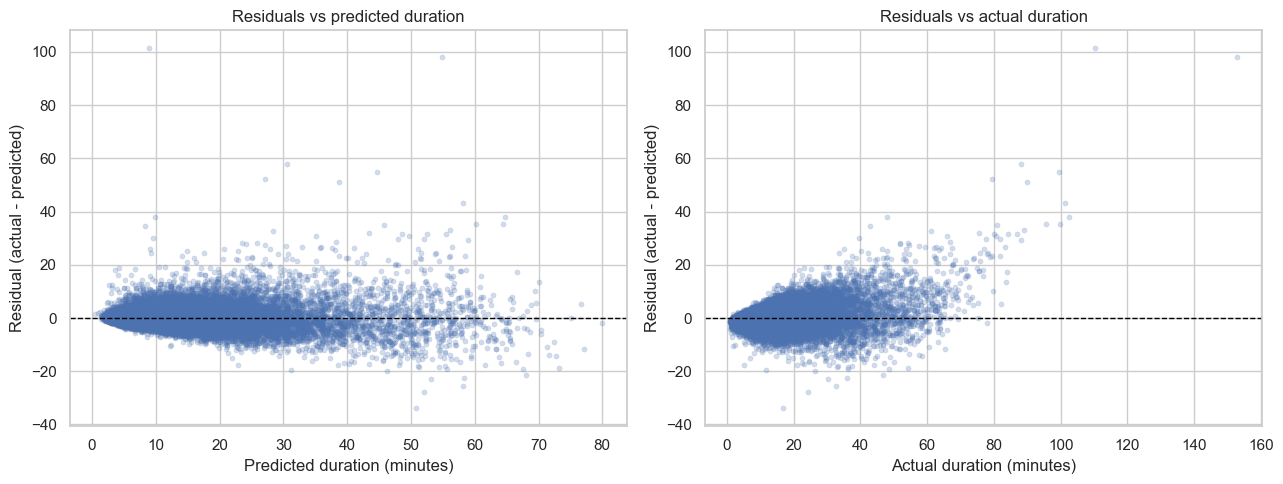

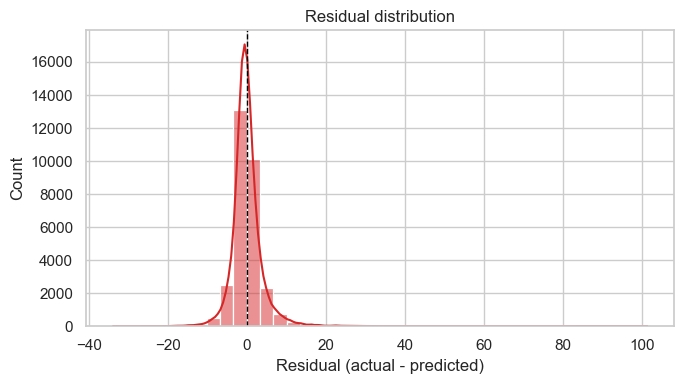

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=eval_results,
    x="predicted_duration_min",
    y="residual",
    s=14,
    alpha=0.25,
    edgecolor=None,
    ax=axes[0],
)
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Residuals vs predicted duration")
axes[0].set_xlabel("Predicted duration (minutes)")
axes[0].set_ylabel("Residual (actual - predicted)")

sns.scatterplot(
    data=eval_results,
    x="actual_duration_min",
    y="residual",
    s=14,
    alpha=0.25,
    edgecolor=None,
    ax=axes[1],
)
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Residuals vs actual duration")
axes[1].set_xlabel("Actual duration (minutes)")
axes[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(eval_results["residual"], bins=40, kde=True, color="#d62728")
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.title("Residual distribution")
plt.xlabel("Residual (actual - predicted)")
plt.tight_layout()
plt.show()

### 6.1 Residual Interpretation

This short interpretation connects the residual plots to model behavior.


In [ ]:
worst20_underprediction_share = (worst20["residual"] > 0).mean()

print(
    "The residual cloud stays close to zero for many ordinary trips, but the spread gets wider as trip duration gets larger. "
    f"Many of the biggest outliers are positive residuals, and {worst20_underprediction_share:.0%} of the 20 largest errors are underpredictions."
)

The residual cloud stays close to zero for many ordinary trips, but the spread gets wider as trip duration gets larger. Many of the biggest outliers are positive residuals, and 95% of the 20 largest errors are underpredictions.


## 7. Group-Based and Worst-Case Error Checks

From **Tarun_mod_eval.ipynb**. The group checks compare rush-hour vs non-rush-hour errors and short/medium/long trip errors. The worst-case table then shows the largest absolute misses.


### 7.1 Group-Based Duration Error Checks

Rush-hour grouping uses the engineered `is_rush_hour` flag when available. Trip-length grouping uses the engineered `distance_category` feature when available.


Rush hour vs non-rush hour
rush_hour_group  trips  mean_actual  mean_predicted   mae  rmse  mean_residual  median_abs_error
  Non-rush hour  20359       14.261          14.280 2.527 3.992         -0.019             1.689
      Rush hour   9641       13.767          13.767 2.450 3.686         -0.001             1.674

Trip length groups
trip_length_group  trips  mean_actual  mean_predicted   mae  rmse  mean_residual  median_abs_error
            short  18302     8.618000        8.607000 1.793 2.632          0.011             1.339
           medium   7424    17.305000       17.360001 2.826 3.864         -0.055             2.180
             long   4274    32.023998       32.068001 4.974 7.139         -0.044             3.618



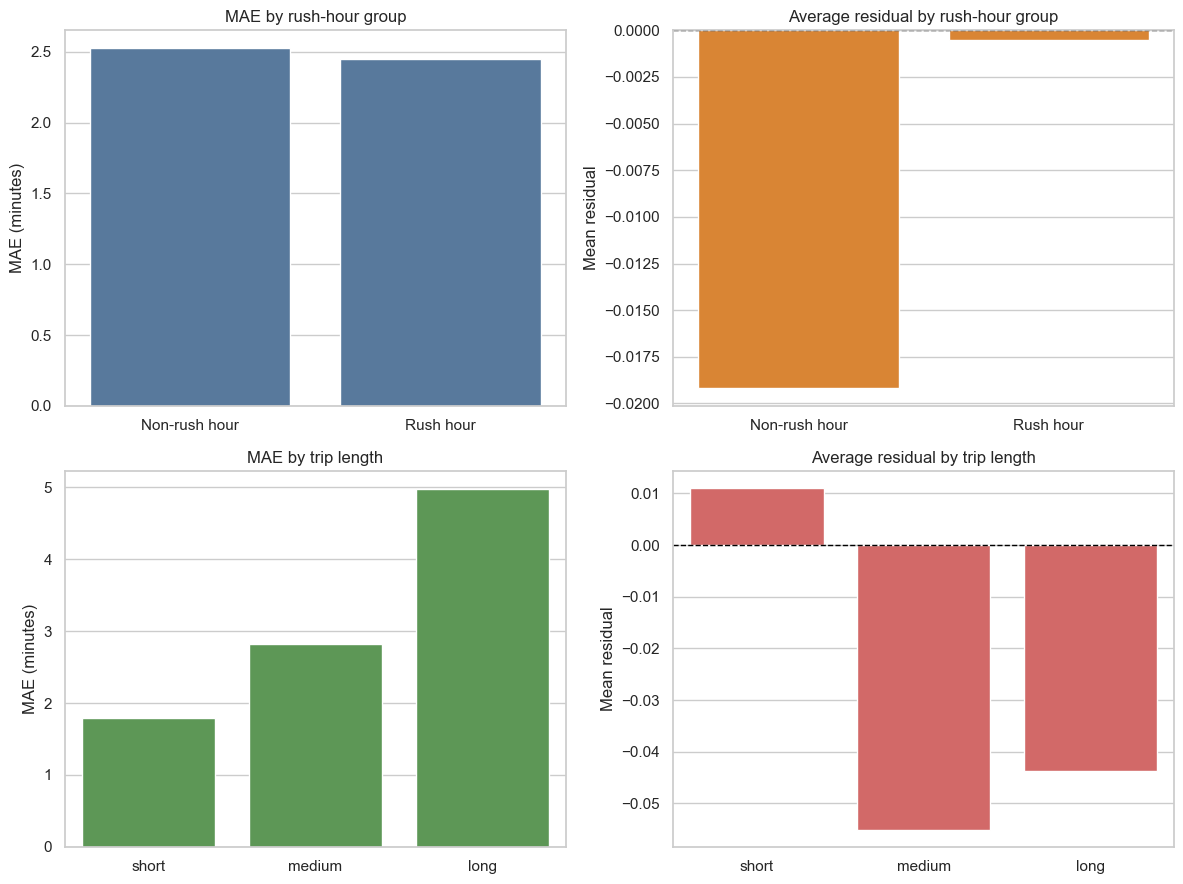

The rush-hour comparison does not show a major performance drop in this sample. MAE is 2.45 minutes during rush hour versus 2.53 minutes outside rush hour.
Trip length matters much more. MAE rises from 1.79 minutes on short trips to 4.97 minutes on long trips, so the model is much more reliable on ordinary short rides than on long rides.


In [ ]:
print("Rush hour vs non-rush hour")
print(rush_summary.round(3).to_string(index=False))
print()
print("Trip length groups")
print(distance_summary.round(3).to_string(index=False))
print()
distance_plot_order = [group for group in ["short", "medium", "long"] if group in distance_summary["trip_length_group"].tolist()]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=rush_summary, x="rush_hour_group", y="mae", color="#4c78a8", ax=axes[0, 0])
axes[0, 0].set_title("MAE by rush-hour group")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("MAE (minutes)")

sns.barplot(data=rush_summary, x="rush_hour_group", y="mean_residual", color="#f58518", ax=axes[0, 1])
axes[0, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0, 1].set_title("Average residual by rush-hour group")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Mean residual")

sns.barplot(
    data=distance_summary[distance_summary["trip_length_group"].isin(distance_plot_order)],
    x="trip_length_group",
    y="mae",
    order=distance_plot_order,
    color="#54a24b",
    ax=axes[1, 0],
)
axes[1, 0].set_title("MAE by trip length")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("MAE (minutes)")

sns.barplot(
    data=distance_summary[distance_summary["trip_length_group"].isin(distance_plot_order)],
    x="trip_length_group",
    y="mean_residual",
    order=distance_plot_order,
    color="#e45756",
    ax=axes[1, 1],
)
axes[1, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1, 1].set_title("Average residual by trip length")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean residual")

plt.tight_layout()
plt.show()

rush_mae = rush_summary.loc[rush_summary["rush_hour_group"] == "Rush hour", "mae"].iloc[0]
non_rush_mae = rush_summary.loc[rush_summary["rush_hour_group"] == "Non-rush hour", "mae"].iloc[0]

short_mae = distance_summary.loc[distance_summary["trip_length_group"] == "short", "mae"].iloc[0]
long_mae = distance_summary.loc[distance_summary["trip_length_group"] == "long", "mae"].iloc[0]

print(
    f"The rush-hour comparison does not show a major performance drop in this sample. MAE is {rush_mae:.2f} minutes during rush hour versus {non_rush_mae:.2f} minutes outside rush hour."
)
print(
    f"Trip length matters much more. MAE rises from {short_mae:.2f} minutes on short trips to {long_mae:.2f} minutes on long trips, so the model is much more reliable on ordinary short rides than on long rides."
)

### 7.2 Worst Prediction Cases

The table below keeps Tarun's largest absolute-error cases and the practical summary of where the advanced duration model struggles most.


In [ ]:
worst_case_columns = [
    "row_id",
    "actual_duration_min",
    "predicted_duration_min",
    "residual",
    "abs_error",
    "trip_distance",
    "trip_length_group",
    "pickup_hour",
    "rush_hour_group",
    "pickup_borough",
    "dropoff_borough",
    "is_airport_trip",
    "is_same_borough",
]

worst_cases_display = worst_cases[worst_case_columns].round(2)
print(worst_cases_display.to_string(index=False))
print()

worst20_long_share = (worst20["trip_length_group"] == "long").mean()
worst20_airport_share = worst20["is_airport_trip"].mean() if "is_airport_trip" in worst20.columns else np.nan
worst20_rush_share = (worst20["rush_hour_group"] == "Rush hour").mean()
worst20_actual_mean = worst20["actual_duration_min"].mean()
worst20_pred_mean = worst20["predicted_duration_min"].mean()

if "borough_route" in worst20.columns:
    top_routes = worst20["borough_route"].value_counts().head(3)
    route_text = ", ".join([f"{route} ({count})" for route, count in top_routes.items()])
else:
    route_text = "route information was not available"

print(
    f"Most of the biggest misses are underpredictions. The 20 worst cases average {worst20_actual_mean:.1f} actual minutes but only {worst20_pred_mean:.1f} predicted minutes."
)
print(
    f"Among the 20 worst errors, {worst20_long_share:.0%} are long trips and {worst20_airport_share:.0%} involve an airport. Only {worst20_rush_share:.0%} happen during rush hour."
)
print(
    f"The most common borough routes in the worst cases are {route_text}. In plain English, the model seems to struggle most when a trip turns into an unusually long Queens/Manhattan or airport-related ride."
)

 row_id  actual_duration_min  predicted_duration_min   residual  abs_error  trip_distance trip_length_group  pickup_hour rush_hour_group pickup_borough dropoff_borough  is_airport_trip  is_same_borough
  69573           110.300003                8.970000 101.330002 101.330002       1.600000             short           23   Non-rush hour      Manhattan       Manhattan                0                1
 172395           152.830002               54.830002  98.000000  98.000000      18.330000              long           12   Non-rush hour      Manhattan       Manhattan                0                1
1549760            88.220001               30.520000  57.700001  57.700001       5.610000              long           16   Non-rush hour      Manhattan          Queens                1                0
1812716            99.650002               44.730000  54.919998  54.919998      24.920000              long            6   Non-rush hour         Queens       Manhattan                0        

## 8. Final Comparison Summary

Across the individual Section 6 notebooks, the evaluation pattern is consistent: linear/logistic baselines are useful references, but tree-based ensemble models perform better for both project targets.

| Task | Model / check | Source notebook | Key result preserved here |
|------|---------------|-----------------|---------------------------|
| Trip duration | Linear Regression baseline | Abhishek_mod_eval.ipynb | Test RMSE 5.32 minutes, MAE 3.72, R^2 0.7477 |
| Trip duration | Random Forest regressor | Abhishek_mod_eval.ipynb | Test RMSE 3.99 minutes, MAE 2.61, R^2 0.8579 |
| Trip duration | XGBoost regressor | Tarun_mod_eval.ipynb | Test RMSE 3.896 minutes, MAE 2.502, R^2 0.866 |
| Congestion fee | Logistic Regression baseline | Abhishek_mod_eval.ipynb / Moses_mod_eval.ipynb | ROC-AUC about 0.734 |
| Congestion fee | Random Forest classifier | Abhishek_mod_eval.ipynb / Morgan_mod_eval.ipynb / Moses_mod_eval.ipynb | F1 about 0.968 and ROC-AUC 0.9794 |
| Congestion fee | XGBoost classifier | Morgan_mod_eval.ipynb / Moses_mod_eval.ipynb | Best classification result: F1 0.9755 and ROC-AUC 0.9850 |
| Residual / group checks | XGBoost duration errors | Tarun_mod_eval.ipynb | Long and airport-related trips explain many of the largest misses |
| Hourly checks | XGBoost congestion-fee classification | Morgan_mod_eval.ipynb | Performance varies slightly by hour, especially around heavier traffic periods |

Overall, Section 6 supports using ensemble methods for final modeling. For trip duration, XGBoost gives the strongest overall fit, while residual and worst-case checks show that unusually long and airport-related trips remain the main failure cases. For congestion-fee prediction, Random Forest and XGBoost substantially improve over the logistic baseline, with XGBoost producing the strongest F1 and ROC-AUC in the individual evaluation notebooks.